# Graded Response Model — EQSQ (Single Scale)

Fits a single-dimensional GRM to all 120 EQSQ items.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data

In [2]:
from bayesianquilts.data.eqsq import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {response_cardinality} categories")
df.head()

Dataset: 13256 people, 120 items, 4 categories


person,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29,E30,E31,E32,E33,E34,E35,E36,…,S24,S25,S26,S27,S28,S29,S30,S31,S32,S33,S34,S35,S36,S37,S38,S39,S40,S41,S42,S43,S44,S45,S46,S47,S48,S49,S50,S51,S52,S53,S54,S55,S56,S57,S58,S59,S60
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,2,0,2,1,3,2,0,2,0,2,0,0,3,3,3,2,2,0,1,3,2,3,0,0,2,1,2,2,3,2,1,0,3,3,1,1,…,0,2,1,2,2,3,2,1,0,3,3,1,1,3,3,3,0,1,3,0,2,1,3,1,2,3,1,0,3,1,3,2,1,0,3,3,2
1,3,2,2,1,1,1,1,2,3,3,2,3,1,0,0,2,1,3,2,0,2,3,2,3,0,3,3,2,2,0,3,1,0,0,1,3,…,3,0,3,3,2,2,0,3,1,0,0,1,3,0,1,1,3,1,3,1,2,3,2,2,1,0,2,2,2,3,1,2,3,3,2,3,1
2,2,2,2,0,0,1,1,1,2,0,3,1,1,1,2,2,2,1,0,0,0,2,3,1,0,3,1,3,0,2,1,1,0,0,1,1,…,1,0,3,1,3,0,2,1,1,0,0,1,1,0,3,1,3,0,2,3,3,3,2,3,0,0,2,3,2,0,2,0,2,3,2,1,3
3,1,1,1,0,1,0,2,1,3,3,1,2,3,2,1,2,1,1,1,3,1,0,0,0,2,0,1,2,0,0,1,3,1,2,0,2,…,0,2,0,1,2,0,0,1,3,1,2,0,2,1,0,1,1,1,2,1,1,2,2,2,2,3,1,2,1,2,1,2,1,2,2,3,0
4,2,0,1,3,3,1,2,2,1,2,0,0,3,0,3,2,0,0,2,3,1,3,0,1,2,0,2,0,2,3,1,0,3,3,1,2,…,1,2,0,2,0,2,3,1,0,3,3,1,2,2,2,3,1,2,1,0,3,2,3,0,2,2,3,1,0,3,0,2,1,0,2,3,0


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 13256


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)
n_bad = sum(np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality)) for k in item_keys)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 512
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 7420
N: 13256, Batch size: 512, Steps per epoch: 26


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=1e-4,
    patience=10,
    clip_norm=1.,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
    lr_decay_factor=0.975,
)
losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Baseline final loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000100):   0%|          | 0/26 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000100):   0%|          | 0/26 [00:01<?, ?batch/s, best_loss=inf, loss=179.0794]

Epoch 1/200 (LR: 0.000100):   4%|▍         | 1/26 [00:01<00:40,  1.61s/batch, best_loss=inf, loss=179.0794]

Epoch 1/200 (LR: 0.000100):   4%|▍         | 1/26 [00:01<00:40,  1.61s/batch, best_loss=inf, loss=178.5313]

...

Epoch 19/200 (LR: 0.000068):  77%|███████▋  | 20/26 [00:00<00:00, 40.67batch/s, best_loss=175.7245, loss=176.8855]

Epoch 19/200 (LR: 0.000068):  77%|███████▋  | 20/26 [00:00<00:00, 40.67batch/s, best_loss=175.7245, loss=176.8411]

Epoch 19/200 (LR: 0.000068):  96%|█████████▌| 25/26 [00:00<00:00, 40.45batch/s, best_loss=175.7245, loss=176.8411]

Epoch 19/200 (LR: 0.000068):  96%|█████████▌| 25/26 [00:00<00:00, 40.45batch/s, best_loss=175.7245, loss=158.3737]

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000067

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
NaN/Inf recovery was triggered 4 times during training.
Baseline final loss: 176.22


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
# Calibrate baseline model early so we can compute WAIC for mixed imputation
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit Pairwise Ordinal Stacking Model

In [8]:
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

imputation_df = sub_df.select(item_keys).to_pandas()
imputation_df = imputation_df.replace(-1, float('nan'))
print(f"NaN count: {imputation_df.isna().sum().sum()}")

pairwise_model = PairwiseOrdinalStackingModel(
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)
pairwise_model.fit(
    X_df=imputation_df,
    n_jobs=1,
    n_top_features=60,
    seed=42,
    save_dir='pairwise_checkpoint',
)

NaN count: 7420
Computing feature correlations...


Fitting PairwiseOrdinalStackingModel
  Variables: 120
  Observations: 13256
  Min obs per model: 5
  Parallel jobs: 1
  Top features per target: 60
  DM alpha prior: 0.5
  Global ordinal values: [0. 1. 2. 3.] (n=4)

Fitting marginal regression models...
  120 of 120 remaining


  Var 0 (E1): elpd/n=-0.0520


  Var 1 (E2): elpd/n=-0.0427


  Var 2 (E3): elpd/n=-0.0461


...

  DM (S20->S60): elpd/n=-1.2980, n=13176
  DM (S21->S60): elpd/n=-1.3099, n=13127
  DM (S22->S60): elpd/n=-1.2988, n=13148
  DM (S23->S60): elpd/n=-1.2556, n=13178
  DM (S24->S60): elpd/n=-1.2984, n=13152
  DM (S25->S60): elpd/n=-1.3054, n=13132
  DM (S26->S60): elpd/n=-1.2492, n=13179
  DM (S27->S60): elpd/n=-1.3088, n=13186
  DM (S28->S60): elpd/n=-1.2818, n=13192
  DM (S29->S60): elpd/n=-1.3069, n=13159


  DM (S30->S60): elpd/n=-1.2848, n=13138
  DM (S31->S60): elpd/n=-1.3058, n=13163
  DM (S32->S60): elpd/n=-1.2795, n=13125
  DM (S33->S60): elpd/n=-1.2946, n=13181
  DM (S34->S60): elpd/n=-1.3069, n=13119
  DM (S35->S60): elpd/n=-1.2981, n=13067
  DM (S36->S60): elpd/n=-1.3120, n=13152
  DM (S37->S60): elpd/n=-1.2639, n=13139
  DM (S38->S60): elpd/n=-1.2850, n=13187
  DM (S39->S60): elpd/n=-1.3082, n=13127


  DM (S40->S60): elpd/n=-1.3063, n=13139
  DM (S41->S60): elpd/n=-1.2758, n=13160
  DM (S42->S60): elpd/n=-1.2916, n=13148
  DM (S43->S60): elpd/n=-1.3009, n=13163
  DM (S44->S60): elpd/n=-1.3002, n=13189
  DM (S45->S60): elpd/n=-1.2375, n=13184
  DM (S46->S60): elpd/n=-1.3081, n=13179
  DM (S47->S60): elpd/n=-1.3077, n=13170
  DM (S48->S60): elpd/n=-1.2427, n=13134
  DM (S49->S60): elpd/n=-1.2903, n=13172


  DM (S50->S60): elpd/n=-1.3100, n=13204
  DM (S51->S60): elpd/n=-1.2613, n=13171
  DM (S52->S60): elpd/n=-1.3086, n=13169
  DM (S53->S60): elpd/n=-1.0978, n=13181
  DM (S54->S60): elpd/n=-1.3091, n=13182
  DM (S55->S60): elpd/n=-1.2133, n=13181
  DM (S56->S60): elpd/n=-1.2856, n=13154
  DM (S57->S60): elpd/n=-1.2837, n=13127
  DM (S58->S60): elpd/n=-1.2951, n=13147
  DM (S59->S60): elpd/n=-1.2724, n=13163



Completed:
  Regression marginal: 120/120
  Regression univariate: 7121/7200
  DM marginal: 120/120
  DM pairwise: 14280/14280


In [9]:
pairwise_model.save('pairwise_stacking_model.yaml')
pairwise_model.compute_optimal_stacking_weights()

Optimal stacking weights computed for 120 targets


In [10]:
import pandas as pd

def compare_stacking_weights(model, item_keys):
    """Compare default softmax vs optimal Yao et al. stacking weights."""
    rows = []
    for i, item_key in enumerate(item_keys):
        models_info = []
        if i in model.marginal_results:
            zr = model.marginal_results[i]
            if zr.converged:
                models_info.append(("reg:intercept", zr.elpd_loo_per_obs, zr.elpd_loo_per_obs_se, 0.0))
        for (t, p), r in model.univariate_results.items():
            if t == i and r.converged:
                pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                models_info.append((f"reg:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_zero_results") and i in model.dm_zero_results:
            dmz = model.dm_zero_results[i]
            if dmz.converged:
                models_info.append(("dm:marginal", dmz.elpd_loo_per_obs, dmz.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_results"):
            for (t, p), r in model.dm_results.items():
                if t == i and r.converged:
                    pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                    models_info.append((f"dm:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        n_models = len(models_info)
        if n_models == 0:
            rows.append({"Item": item_key, "N": 0, "Eff_def": "-", "Eff_opt": "-",
                         "Top_default": "-", "w_def": "-", "Top_optimal": "-", "w_opt": "-"})
            continue
        elpds = np.array([m[1] for m in models_info])
        ses = np.array([m[2] for m in models_info])
        default_w = model._elpd_weights(elpds, ses, 1.0)
        opt_dict = getattr(model, "_optimal_weights", {}).get(i, {})
        opt_w = np.zeros(n_models)
        for j, (name, _, _, _) in enumerate(models_info):
            parts = name.split(":", 1)
            mtype, mid = parts[0], parts[1] if len(parts) > 1 else ""
            if mid in ("intercept", "marginal"):
                key = (mtype[:3], mid)
            elif mid in model.variable_names:
                key = (mtype[:3], model.variable_names.index(mid))
            else:
                key = (mtype[:3], mid)
            opt_w[j] = opt_dict.get(key, 0.0)
        if opt_w.sum() > 0: opt_w /= opt_w.sum()
        def eff_n(w):
            w = w[w > 1e-10]
            return float(np.exp(-np.sum(w * np.log(w)))) if len(w) > 0 else 0
        names = [m[0] for m in models_info]
        rows.append({
            "Item": item_key, "N": n_models,
            "Eff_def": f"{eff_n(default_w):.1f}", "Eff_opt": f"{eff_n(opt_w):.1f}",
            "Top_default": names[np.argmax(default_w)], "w_def": f"{default_w.max():.3f}",
            "Top_optimal": names[np.argmax(opt_w)] if opt_w.sum() > 0 else "-",
            "w_opt": f"{opt_w.max():.3f}",
        })
    return pd.DataFrame(rows)

weights_df = compare_stacking_weights(pairwise_model, item_keys)
print("Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)\n")
print(weights_df.to_string(index=False))

Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)

Item   N Eff_def Eff_opt Top_default w_def   Top_optimal w_opt
  E1 181   149.4   181.0       dm:S1 0.011 reg:intercept 0.006
  E2 179   155.8   179.0       dm:S2 0.010 reg:intercept 0.006
  E3 181   153.9   181.0       dm:S3 0.010 reg:intercept 0.006
  E4 180   148.9   180.0       dm:S4 0.011 reg:intercept 0.006
  E5 181   149.1   181.0       dm:S5 0.011 reg:intercept 0.006
  E6 180   147.2   180.0       dm:S6 0.011 reg:intercept 0.006
  E7 181   152.1   181.0       dm:S7 0.011 reg:intercept 0.006
  E8 180   148.1   180.0       dm:S8 0.011 reg:intercept 0.006
  E9 181   149.6   181.0       dm:S9 0.011 reg:intercept 0.006
 E10 180   150.8   180.0      dm:S10 0.011 reg:intercept 0.006
 E11 179   148.4   179.0      dm:S11 0.011 reg:intercept 0.006
 E12 179   150.2   179.0      dm:S12 0.011 reg:intercept 0.006
 E13 178   148.7   178.0      dm:S13 0.011 reg:intercept 0.006
 E14 181   149.8   181.0      dm:S14 0.011 reg:inter

## 4b. Fit Pairwise-Only GRM

Uses only the pairwise ordinal stacking ensemble (no IRT blending, w=1 for all items).

In [11]:
from bayesianquilts.imputation.mixed import PairwiseOnlyImputationModel

pairwise_imputation = PairwiseOnlyImputationModel(mice_model=pairwise_model)

model_pairwise = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    imputation_model=pairwise_imputation,
    dtype=jnp.float64,
)

print("Warm-starting from baseline model parameters")

res_pairwise = model_pairwise.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=1e-4,
    clip_norm=1.,
    patience=10,
    zero_nan_grads=True,
    initial_values=model_baseline.params,
    lr_decay_factor=0.975,
)

losses_pairwise = res_pairwise[0]
print(f"Pairwise final loss: {losses_pairwise[-1]:.2f}")
model_pairwise.save_to_disk('grm_pairwise')

Warm-starting from baseline model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000100):   0%|          | 0/26 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000100):   0%|          | 0/26 [00:02<?, ?batch/s, best_loss=inf, loss=177.8066]

Epoch 1/200 (LR: 0.000100):   4%|▍         | 1/26 [00:02<01:06,  2.67s/batch, best_loss=inf, loss=177.8066]

Epoch 1/200 (LR: 0.000100):   4%|▍         | 1/26 [00:02<01:06,  2.67s/batch, best_loss=inf, loss=177.3854]

...

Epoch 11/200 (LR: 0.000054): 100%|██████████| 26/26 [00:17<00:00,  1.46batch/s, best_loss=176.6313, loss=158.2850]

  -> No improvement in loss for 9 check(s).                    
  -> Decaying learning rate to: 0.000053


Epoch 12/200 (LR: 0.000053):   0%|          | 0/26 [00:00<?, ?batch/s]

❌ Maximum NaN recovery attempts (10) exceeded. Stopping training.


Pairwise final loss: 176.70


In [12]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=pairwise_model,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

MICE pointwise ELPD computed for 120 items, 13256 people


Item Stacking Weights (Yao et al. 2018, MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt  khat_irt
-----------------------------------------------------
E1              1.000    -1.2616    -1.3484     0.000
E2              1.000    -1.0790    -1.6494     0.000
E3              0.990    -1.1664    -1.3226     0.000
E4              0.934    -1.2635    -1.3643     0.000
E5              1.000    -1.2320    -1.4241     0.000
E6              1.000    -1.2916    -1.3954     0.000
E7              1.000    -1.1784    -1.3021     0.000
E8              1.000    -1.2870    -1.5407     0.000
E9              1.000    -1.2729    -1.4417     0.000
E10             1.000    -1.2167    -1.4440     0.000
E11             1.000    -1.2271    -1.4831     0.000
E12             1.000    -1.1976    -1.6735     0.000
E13             1.000    -1.1812    -1.3088     0.000
E14             1.000    -1.2590    -1.4577     0.000
E15             1.000    -1.2744    -1.3835     0.000
E16             0.872    -1.

## 5. Fit Mixed GRM (Pairwise + IRT Imputation)

In [13]:
all_pairwise = all(mixed_imputation.get_item_weight(k) >= 1.0 - 1e-6 for k in item_keys)

if all_pairwise:
    print("All w_IRT ≈ 0 — mixed model is identical to pairwise. Reusing pairwise parameters.")
    model_imputed = model_pairwise
    losses_imputed = losses_pairwise
else:
    print(f"IRT contributes to {sum(1 for k in item_keys if mixed_imputation.get_item_weight(k) < 1.0 - 1e-6)}/{len(item_keys)} items")
    model_imputed = GRModel(
        item_keys=item_keys,
        num_people=SUBSAMPLE_N,
        dim=1,
        response_cardinality=response_cardinality,
        dtype=jnp.float64,
        imputation_model=mixed_imputation,
    )

    print("Warm-starting from pairwise model parameters")
    res_imputed = model_imputed.fit(
        data_factory,
        batch_size=BATCH_SIZE,
        dataset_size=SUBSAMPLE_N,
        num_epochs=NUM_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        learning_rate=5e-05,
        clip_norm=1.,
        patience=10,
        zero_nan_grads=True,
        initial_values=model_pairwise.params,
        lr_decay_factor=0.975,
    )
    losses_imputed = res_imputed[0]
    if losses_imputed:
        print(f"Final mixed loss: {losses_imputed[-1]:.2f}")
    else:
        print("Mixed model training failed — falling back to pairwise")
        model_imputed = model_pairwise
        losses_imputed = losses_pairwise

IRT contributes to 20/120 items


Warm-starting from pairwise model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000050):   0%|          | 0/26 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000050):   4%|▍         | 1/26 [00:01<00:30,  1.22s/batch]

🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 1/10
   -> Reduced learning rate to: 0.000049
   -> Reinitialized optimizer and gradient accumulator


...

Epoch 1/200 (LR: 0.000050):  35%|███▍      | 9/26 [00:03<00:05,  3.33batch/s]

🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 9/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000040
   -> Reinitialized optimizer and gradient accumulator


Epoch 1/200 (LR: 0.000050):  38%|███▊      | 10/26 [00:04<00:04,  3.32batch/s]

🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 10/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000039
   -> Reinitialized optimizer and gradient accumulator


❌ Maximum NaN recovery attempts (10) exceeded. Stopping training.
Mixed model training failed — falling back to pairwise


In [14]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

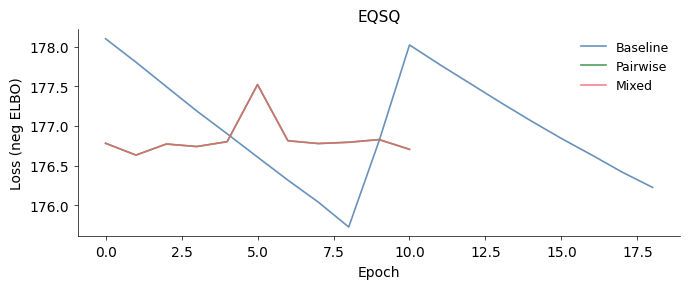

In [15]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='EQSQ',
                          losses_pairwise=losses_pairwise)
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
calibrate_manually(model_pairwise, n_samples=32, seed=103)
calibrate_manually(model_imputed, n_samples=32, seed=102)

## 7. Ignorability Analysis

Compute per-item adaptive thresholds comparing pairwise imputation ELPD
against baseline IRT ELPD. Items whose missing values are **ignorable**
do not benefit from imputation over the baseline's own marginalization.

In [17]:
model_imputed.compute_adaptive_thresholds(
    data_factory, baseline_model=model_baseline, sample_size=32
)

import pandas as pd
ignorability_df = pd.DataFrame([
    {
        'Item': item,
        'w_pairwise': f"{mixed_imputation.get_item_weight(item):.4f}",
        'Threshold': f"{model_imputed._adaptive_thresholds[item]:.4f}",
        'Missing Ignorable': model_imputed._ignorable_items[item],
    }
    for item in item_keys
])
n_ignorable = sum(model_imputed._ignorable_items[k] for k in item_keys)
print(f"Ignorability: {n_ignorable}/{len(item_keys)} items have ignorable missing values\n")
print(ignorability_df.to_string(index=False))

# Re-save model with thresholds persisted
model_imputed.save_to_disk('grm_imputed')

Ignorability: 0/120 items have ignorable missing values

Item w_pairwise Threshold  Missing Ignorable
  E1     1.0000    0.0010              False
  E2     1.0000    0.0010              False
  E3     0.9896    0.0010              False
  E4     0.9344    0.0010              False
  E5     1.0000    0.0010              False
  E6     1.0000    0.0010              False
  E7     1.0000    0.0010              False
  E8     1.0000    0.0010              False
  E9     1.0000    0.0010              False
 E10     1.0000    0.0010              False
 E11     1.0000    0.0010              False
 E12     1.0000    0.0010              False
 E13     1.0000    0.0010              False
 E14     1.0000    0.0010              False
 E15     1.0000    0.0010              False
 E16     0.8722    0.0010              False
 E17     1.0000    0.0010              False
 E18     1.0000    0.0010              False
 E19     1.0000    0.0010              False
 E20     1.0000    0.0010              Fals

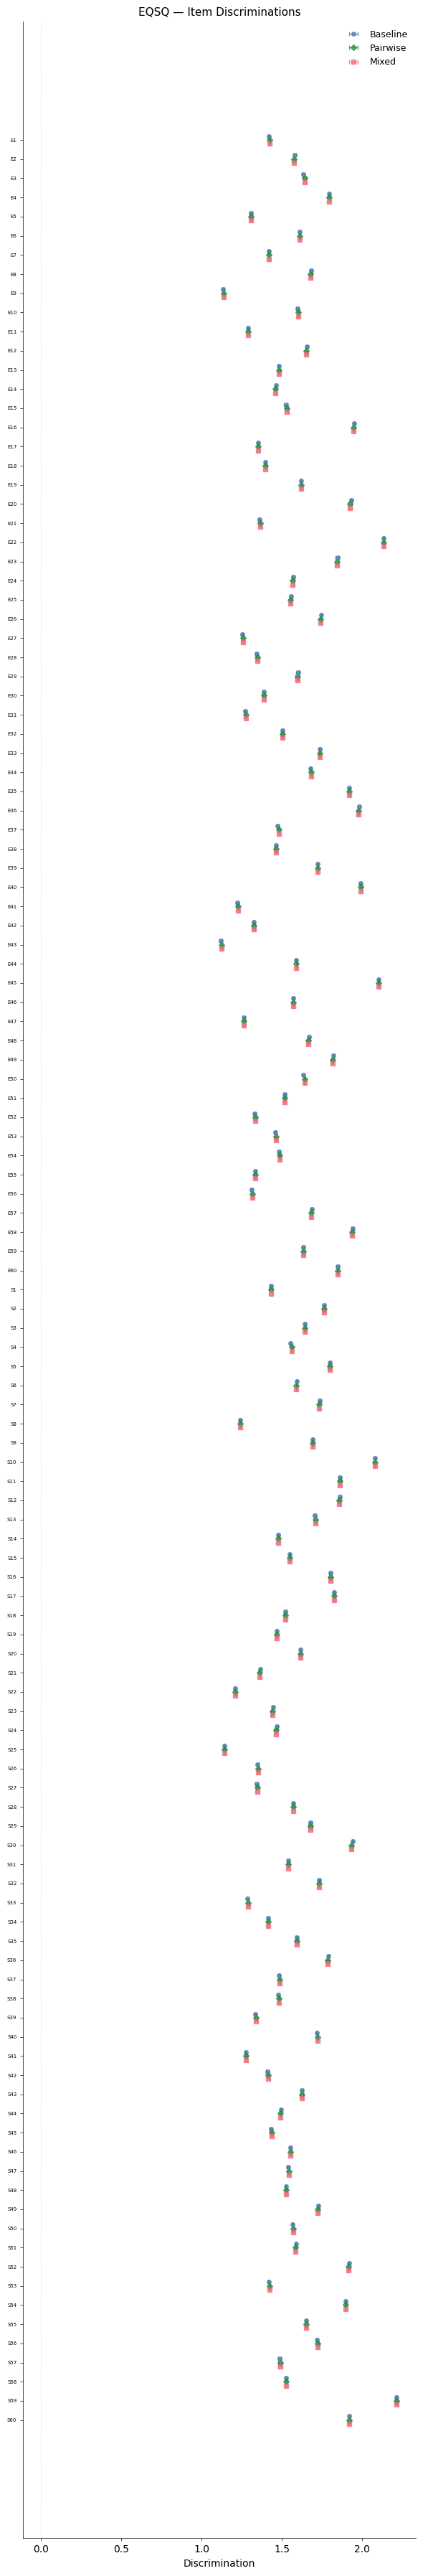

In [18]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed,
                                  title='EQSQ \u2014 Item Discriminations',
                                  model_pairwise=model_pairwise)
fig.savefig('discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

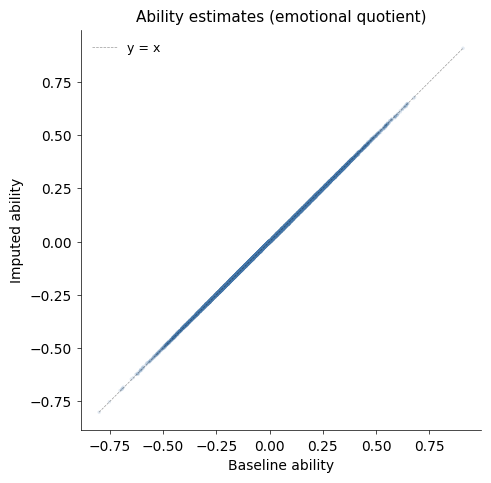

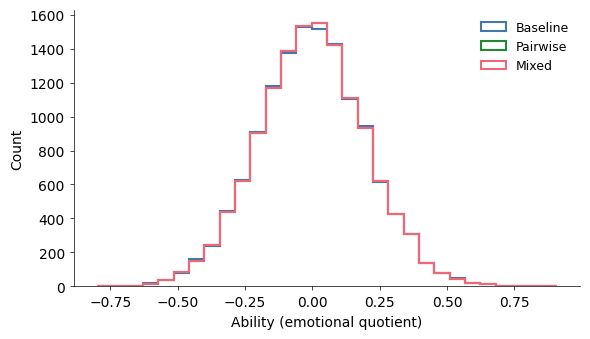

In [19]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_pw = np.array(model_pairwise.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='emotional quotient')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='emotional quotient',
                                  abilities_pairwise=ab_pw)
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

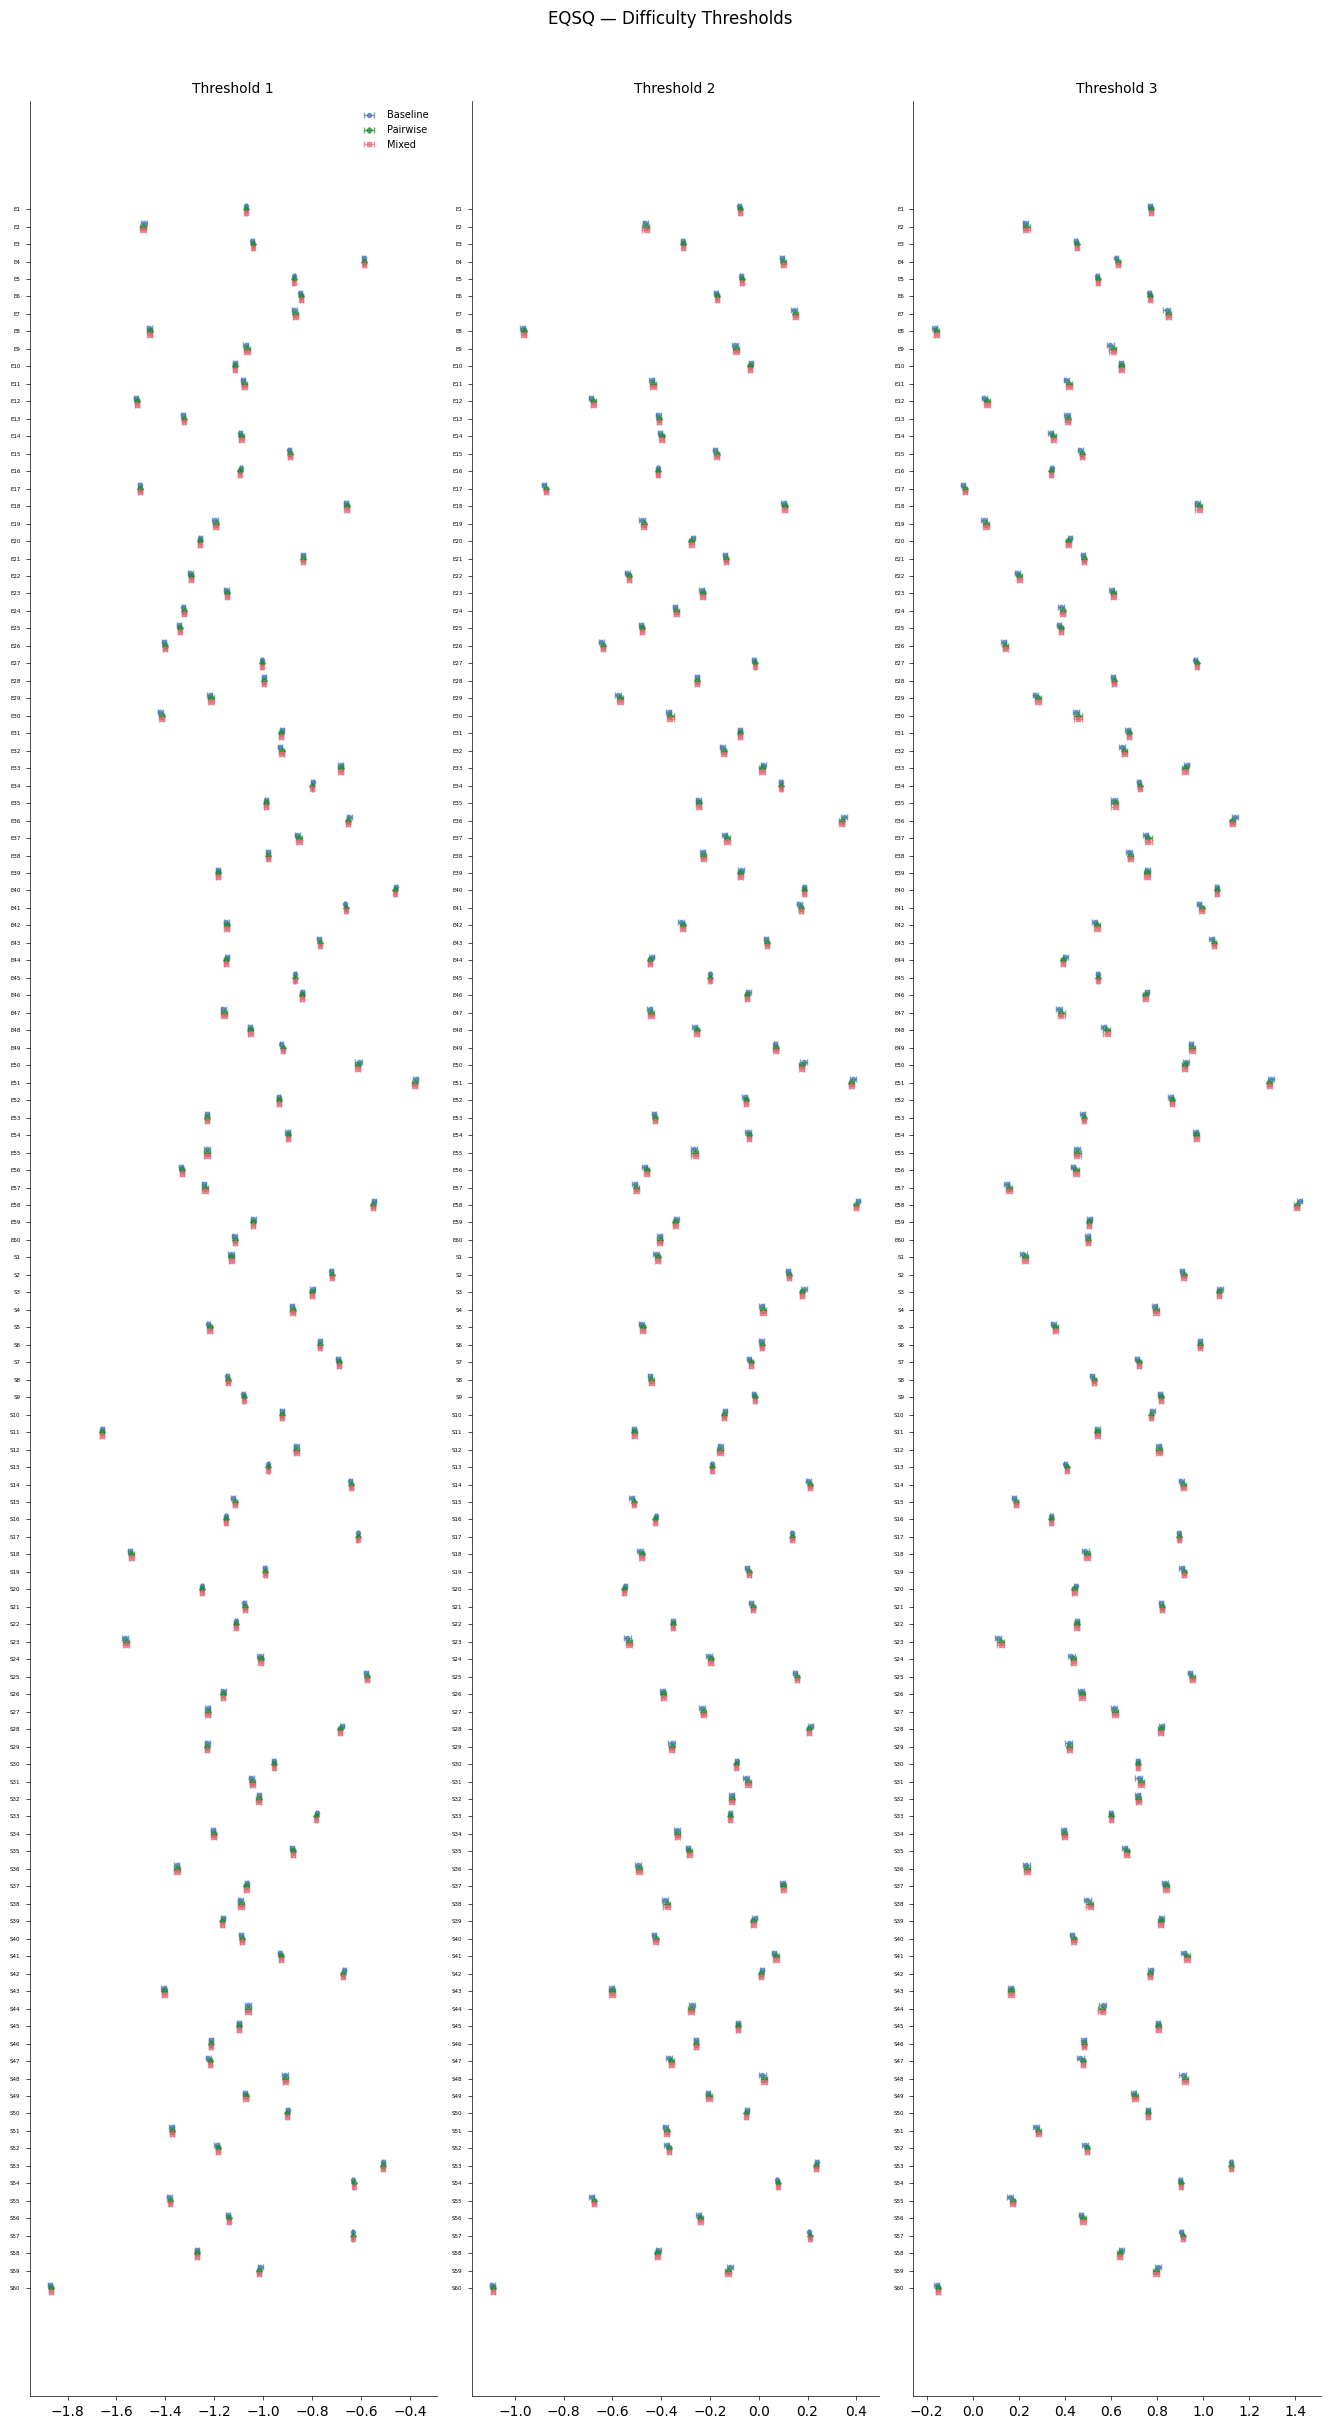

In [20]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed,
                      title='EQSQ \u2014 Difficulty Thresholds',
                      model_pairwise=model_pairwise)
fig.savefig('thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

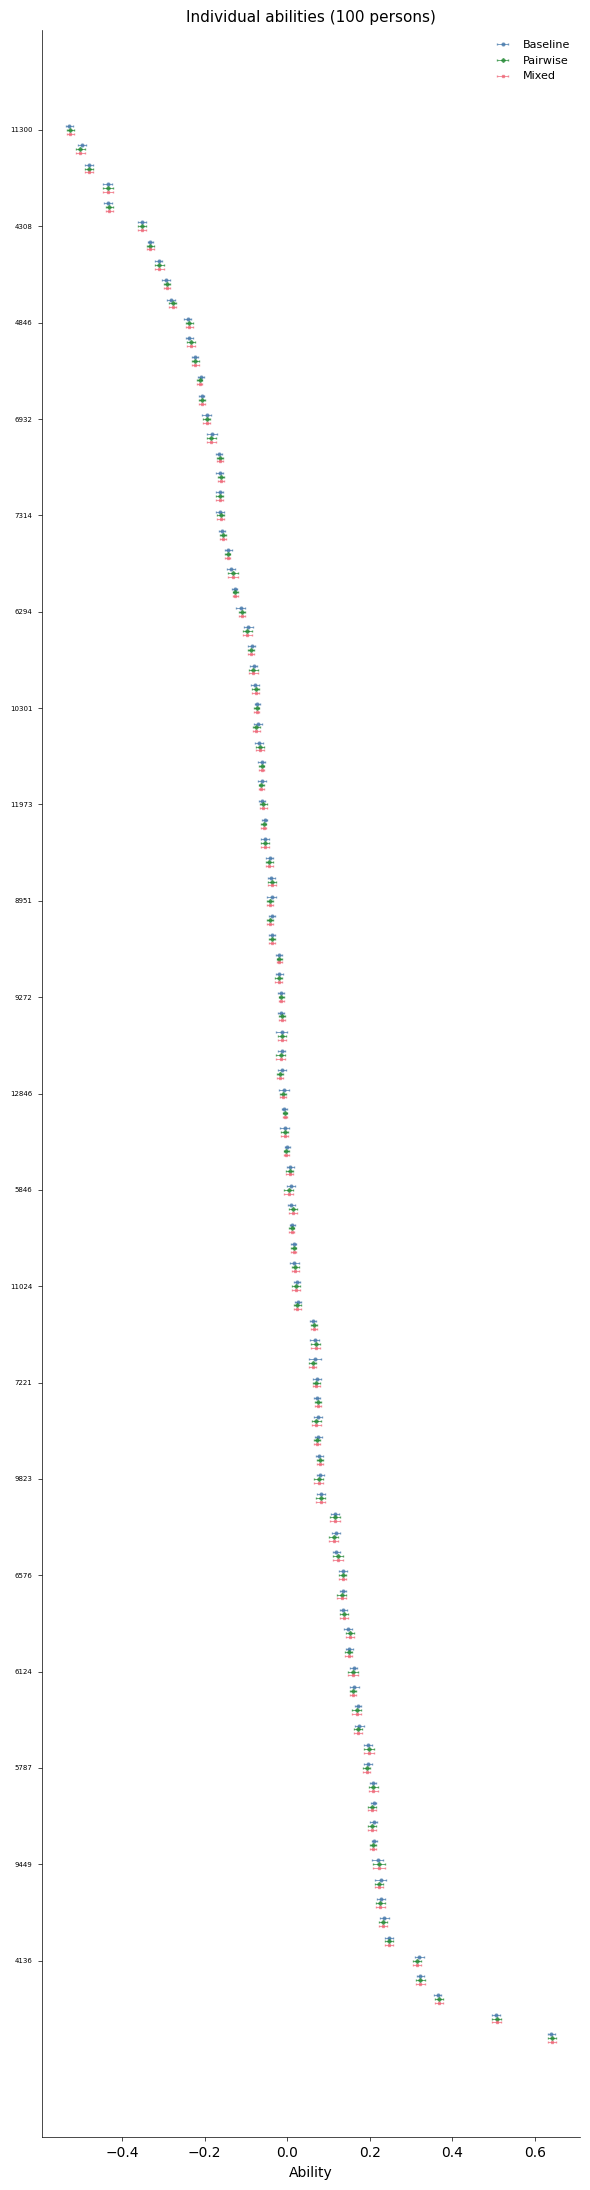

In [21]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed,
                                model_pairwise=model_pairwise)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

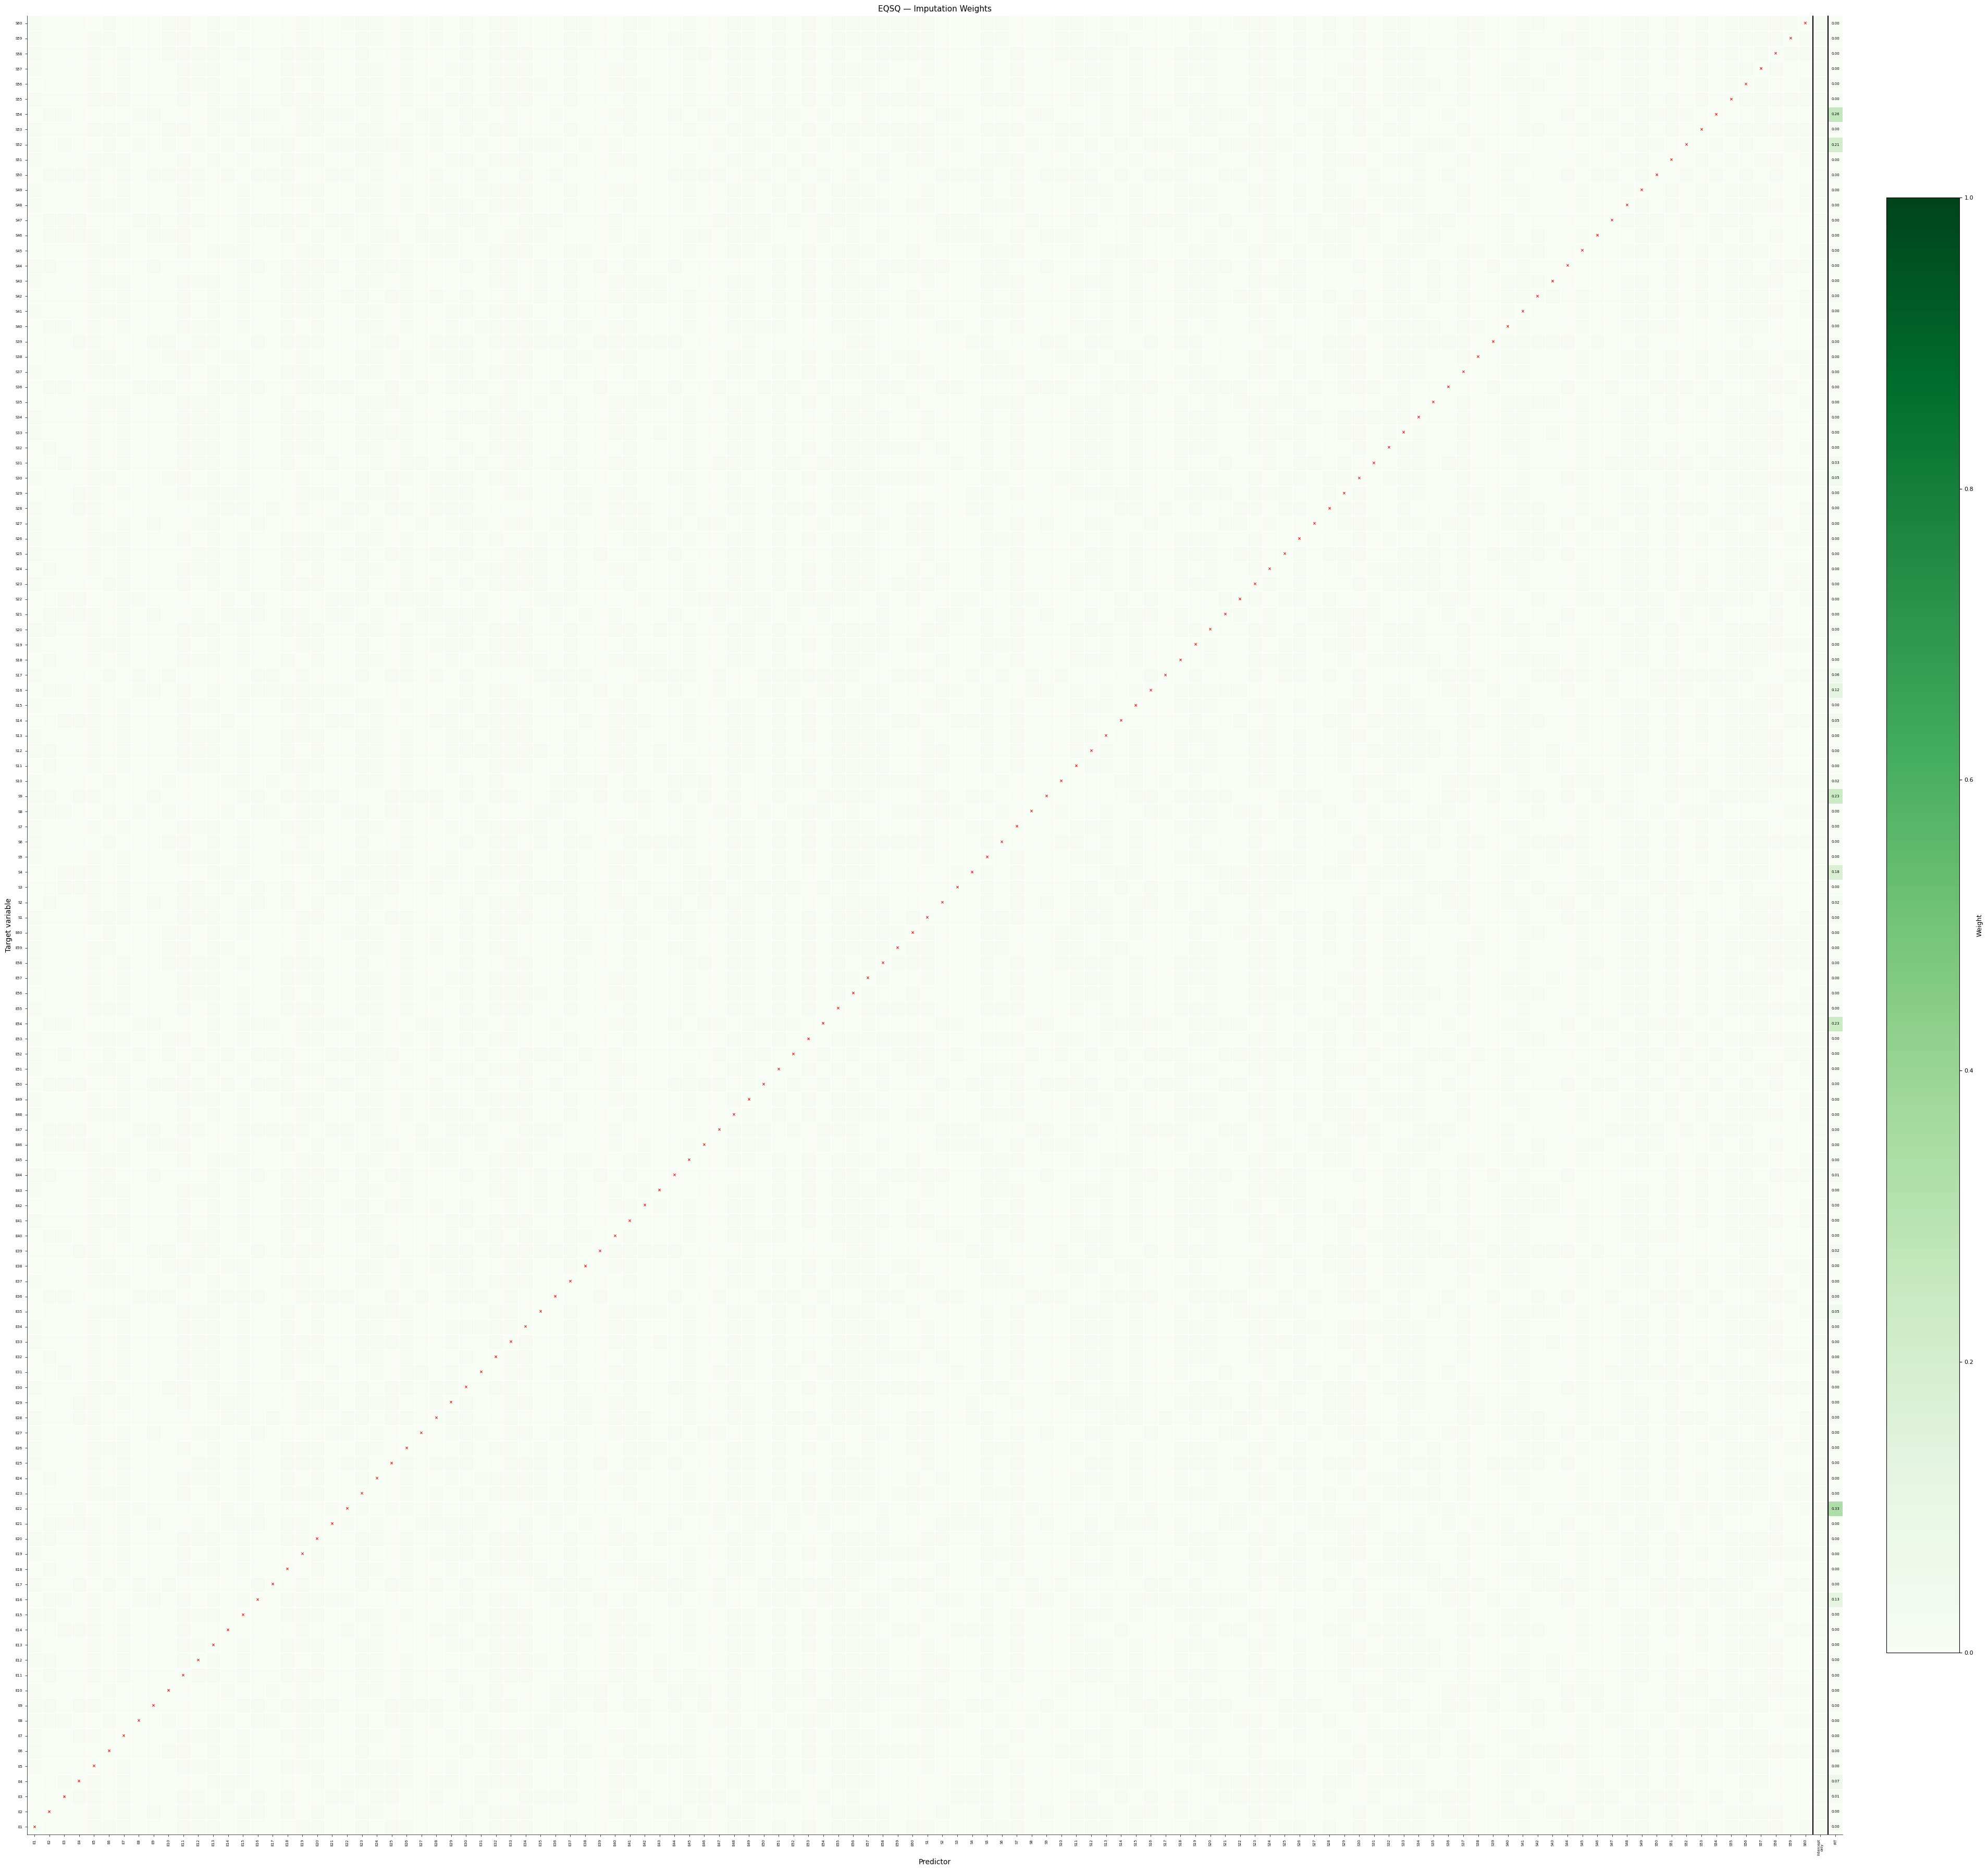

In [22]:
fig = plot_imputation_weights_pcolormesh(pairwise_model, mixed_imputation, item_keys,
                                         title='EQSQ \u2014 Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 8. Model Comparison Table

In [23]:
import pandas as pd
from scipy.stats import spearmanr

def compute_predictive_metrics(model, data_factory, item_keys, response_cardinality):
    K = response_cardinality
    all_ll, all_se, all_nr = [], [], []
    all_pred, all_obs = [], []
    for batch_data in data_factory():
        pred = model.predictive_distribution(batch_data, **model.surrogate_sample)
        probs = np.array(pred['rv'].probs_parameter())
        S, N_batch, I, _ = probs.shape
        for n in range(N_batch):
            ll, se, nr = 0.0, 0.0, 0
            for i, key in enumerate(item_keys):
                y = batch_data[key][n]
                if np.isnan(y) or y < 0 or y >= K: continue
                y_int = int(y)
                p_mean = probs[:, n, i, :].mean(0)
                ll += np.log(np.maximum(probs[:, n, i, y_int].mean(), 1e-30))
                expected = np.sum(p_mean * np.arange(K))
                se += (expected - y_int) ** 2
                all_pred.append(expected)
                all_obs.append(y_int)
                nr += 1
            if nr > 0: all_ll.append(ll); all_se.append(se); all_nr.append(nr)
    ll, se, nr = np.array(all_ll), np.array(all_se), np.array(all_nr)
    N, total = len(ll), nr.sum()
    rho, _ = spearmanr(all_obs, all_pred)
    return {
        'RMSE': (np.sqrt(se.sum()/total), np.std(np.sqrt(se/nr))/np.sqrt(N)),
        'ELPD/n': (ll.mean(), np.std(ll)/np.sqrt(N)),
        'ELPD/resp': (ll.sum()/total, np.std(ll/nr)/np.sqrt(N)),
        'Spearman': (rho, 0.0),
    }

m_b = compute_predictive_metrics(model_baseline, data_factory, item_keys, response_cardinality)
m_p = compute_predictive_metrics(model_pairwise, data_factory, item_keys, response_cardinality)
m_m = compute_predictive_metrics(model_imputed, data_factory, item_keys, response_cardinality)

rows = []
for metric in ['RMSE', 'ELPD/n', 'ELPD/resp', 'Spearman']:
    b_val, b_se = m_b[metric]
    p_val, p_se = m_p[metric]
    m_val, m_se = m_m[metric]
    if metric == 'Spearman':
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.4f}",
            'Pairwise': f"{p_val:.4f}",
            'Mixed': f"{m_val:.4f}",
        })
    else:
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.3f} ({b_se:.3f})",
            'Pairwise': f"{p_val:.3f} ({p_se:.3f})",
            'Mixed': f"{m_val:.3f} ({m_se:.3f})",
        })
print("EQSQ — Predictive Performance Comparison\n")
print(pd.DataFrame(rows).to_string(index=False))


EQSQ — Predictive Performance Comparison

   Metric         Baseline         Pairwise            Mixed
     RMSE    1.056 (0.002)    1.054 (0.002)    1.054 (0.002)
   ELPD/n -172.426 (0.092) -172.110 (0.092) -172.110 (0.092)
ELPD/resp   -1.443 (0.001)   -1.441 (0.001)   -1.441 (0.001)
 Spearman           0.0111           0.0141           0.0141


## Summary

This notebook fitted a single-scale Graded Response Model to all 120 EQSQ
items (E1–E60 + S1–S60) with 4 response categories. Three models were compared:

1. **Baseline GRM** -- treats missing responses as ignorable.
2. **Pairwise GRM** -- uses only the pairwise ordinal stacking ensemble (w=1).
3. **Mixed GRM** -- blends the pairwise ensemble with the baseline IRT model's
   marginalized predictions via per-item stacking weights.